In [1]:
from troncamento_datasets import BaseDataset, SegmentPairDataset
from model import MisalignmentDetector
import torch, torch.nn as nn
import pandas as pd
import os
import tqdm
import utils

In [2]:
device = "mps"

model = MisalignmentDetector().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss(reduction="none")

ckpt = "model_ckpt/train.pt"
if os.path.isfile(ckpt):
    model.load_state_dict(torch.load(ckpt))
    print(f"Loaded trained model from {ckpt}")

model.to("mps")

Loaded trained model from model_ckpt/train.pt


MisalignmentDetector(
  (phone_emb): Embedding(50, 32)
  (pool): AttentionPooling(
    (scorer): Sequential(
      (0): Linear(in_features=1024, out_features=256, bias=True)
      (1): Tanh()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=256, out_features=1, bias=True)
    )
  )
  (shared): Sequential(
    (0): Linear(in_features=1089, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
  )
  (head_bad): Linear(in_features=128, out_features=1, bias=True)
  (head_e): Linear(in_features=128, out_features=1, bias=True)
)

In [3]:
import glob
saved_embed_fs = glob.glob("saved_embeds/*.npy")

df = pd.read_csv("troncamento_data.csv")
df = df[df["sent_it_prob"]>0.99].reset_index(drop=True)

selected_ids = [int(os.path.basename(f).split("_")[0]) for f in saved_embed_fs]
df = df[df["id"].isin(selected_ids)].reset_index(drop=True)

In [4]:
basedataset = BaseDataset(df, dataset_type="target", return_player=False)
df = basedataset.df

In [5]:
from tqdm.auto import tqdm

preds = []
p_es = []
p_bads = []

for idx in tqdm(df.index, desc="Predicting"):
    pred, info = basedataset.predict_sample_label(
        idx,
        model,
        device="mps"
    )
    preds.append(pred)
    p_es.append(info["p_e"])
    p_bads.append(info["p_bad"])

df["predicted_label"] = preds
df["p_e"] = p_es
df["p_bad"] = p_bads

Predicting:   0%|          | 0/29519 [00:00<?, ?it/s]

In [11]:
df.to_csv("troncamento_predictions.csv", index=False)

<Axes: xlabel='predicted_label', ylabel='count'>

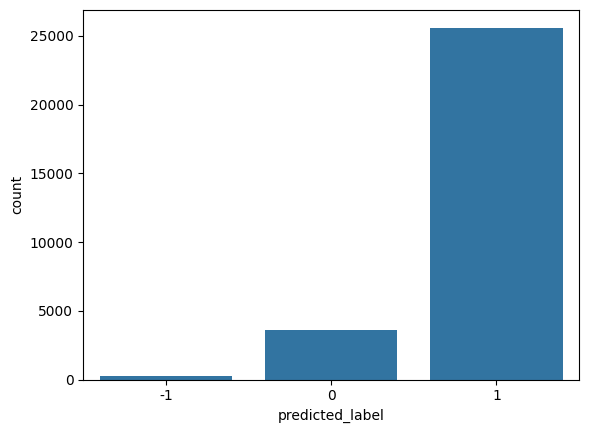

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="predicted_label", data=df)